# Generating time-optimal trajectories

This notebook demonstrates time-optimal trajectory generation in RobotBlockSet. It starts from task-space waypoints, builds the corresponding joint-space path, and computes time-parameterized trajectories that minimize execution time while satisfying velocity, acceleration, and jerk or path constraints.


## Workflow overview

The examples follow the standard workflow for time-optimal trajectory generation:

- define a lightweight robot model,
- construct Cartesian waypoints and corresponding joint configurations,
- generate direct point-to-point jerk-limited motion,
- build a sampled geometric path,
- specify Cartesian and/or joint constraints,
- solve the time-optimal path parameterization,
- visualize the resulting path-space, Cartesian, and joint trajectories.

Use this notebook as both an API reference and a template for adapting the same procedure to a different robot or path.


# Initialization


## Imports


In [1]:
import numpy as np
import scipy.io
from robotblockset.optimal import *

# Use compact numeric printing to make trajectory arrays easier to inspect.
np.set_printoptions(formatter={"float": "{: 0.4f}".format})

from robotblockset.trajectories import cline, gradientPath, gradientCartesianPath, uniqueCartesianPath, jjerk, cjerk, pathoverpoints
from robotblockset.tools import rbs_type
from robotblockset.transformations import map_pose, rot_z, prpy2x

from robotblockset.graphics import plotcpath, plotctraj, plotjtraj

from robotblockset.robots import robot
from robotblockset.robot_spec import panda_spec


## Define robot

Use a lightweight Panda robot model without attaching a simulator scene. This is enough for kinematics, inverse kinematics, and trajectory generation.


In [2]:
class panda_test(panda_spec):
    def __init__(self):
        panda_spec.__init__(self)
        robot.__init__(self)
        self.Init()

    def __del__(self):
        self.Message("Robot deleted", 2)
r = panda_test()

TCP = map_pose(Q=rot_z(-np.pi/4), p=[0, 0, 0.1034])
r.SetTCP(TCP, frame='Flange')
dkin = r.Kinmodel

## Define Cartesian task poses and joint configurations

Array `points_x` stores task poses as position plus roll-pitch-yaw angles: `[x, y, z, roll, pitch, yaw]`. `prpy2x` converts them to the RobotBlockSet compact Cartesian pose representation used by motion commands.

The Cartesian poses are then mapped to joint configurations `points_q` with inverse kinematics.

The last pose repeats the first one, so the path examples form a closed loop. At this stage, these points are only **waypoints**; they are not yet a time-parameterized trajectory.


In [3]:
pte = np.array([
    [0.2, -0.4, 0.4, 0.0, 0.0, np.pi],
    [0.3, -0.2, 0.7, 0.0, 0.0, np.pi / 2],
    [0.3, 0.2, 0.7, np.pi, 0.0, np.pi / 2],
    [0.5, 0.0, 0.6, np.pi / 2, 0.0, np.pi / 2],
    [0.3, -0.2, 0.4, 0.0, 0.0, np.pi],
], dtype=float)

points_x = prpy2x(pte)
points_q, _err = r.IKinPath(points_x, r.q_home, max_iterations=10000)
points_q[-1] = points_q[0]

# Time-optimal trajectory

In **time-optimal trajectory generation**, the geometry of the motion is fixed and the optimizer chooses the timing. The objective is to traverse the motion in the shortest feasible time while respecting velocity, acceleration, and, where applicable, jerk constraints.

Joint torque limits can also be included in principle, but that requires a dynamic robot model. When such a model is not available, practical velocity and acceleration limits still provide useful trajectory bounds.


## Motion between two poses

When only the start and target poses matter, and the intermediate path is not prescribed, a direct jerk-limited trajectory is often sufficient. RobotBlockSet uses the Ruckig-based trajectory generators `jjerk` and `cjerk` for this point-to-point case.


### Joint time-optimal trajectory

`jjerk` generates joint-space motion under velocity, acceleration, and jerk limits. In this example, the third argument `[0, tsamp]` defines the minimum requested duration and the sampling period. If the limits require a longer motion, the trajectory is automatically prolonged and resampled.


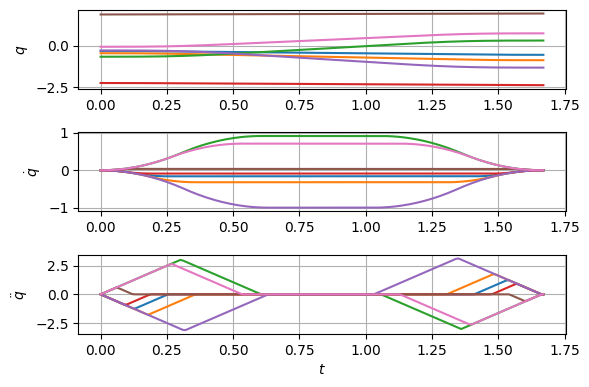

In [4]:
tsamp = 0.01
qt, qdt, qddt = jjerk(points_q[0], points_q[1], [0, tsamp], qd_max=1, qdd_max=5, jerk_max=10)
tt =np.arange(qt.shape[0]) * tsamp
_ = plotjtraj(tt,qt,qdt,qddt, fig_num="Time-optimal joint movement", fig_size=(6,4))

The same motion can be executed directly on a robot with `JMove`:

```python
r.JMove(points_q[1], traj="Jerk", qd_max=1, qdd_max=5, jerk_max=10)
```


### Cartesian time-optimal trajectory

`cjerk` generates Cartesian point-to-point motion under translational/rotational velocity, acceleration, and jerk limits.


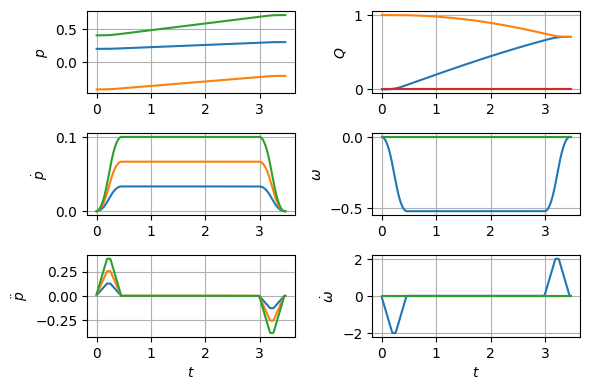

In [5]:
tsamp = 0.01
xt, vt, at = cjerk(points_x[0], points_x[1], [0, tsamp], v_max=np.array([0.2, 0.2, 0.1, 1., 1., 1.]), a_max=2, jerk_max=10)
tt =np.arange(xt.shape[0]) * tsamp
_ = plotctraj(tt, xt, vt, at, fig_num="Time-optimal Cartesian movement", fig_size=(6,4))

The same Cartesian motion can be executed directly on a robot with `CMove`:

```python
r.CMove(points_x[1], traj="Jerk", v_max=np.array([0.2, 0.2, 0.1, 1.0, 1.0, 1.0]), a_max=2, jerk_max=10)
```


## Motion along a path

When the robot must follow intermediate waypoints, the geometric path is fixed and only the timing along the path is optimized. RobotBlockSet uses `timeopttraj` for this case. The method computes time-optimal timing along a fixed path while enforcing joint and Cartesian velocity and acceleration limits.


### Define path

The process starts with a geometric path. A path represented by consecutive samples can usually be described as a parametric curve:

$$
\begin{aligned}
\mathbf{x}(s) &= \mathbf{f}(s),\\
\mathbf{v}_p &= \mathbf{J}_s \dot{s},\\
\dot{\mathbf{v}}_p &= \mathbf{J}_s \ddot{s} + \mathbf{J}'_s \dot{s}^2.
\end{aligned}
$$

Here, $\mathbf{f}(\cdot)$ is the path function, $s$ is the path parameter, and $s \in [s_0, s_1]$.


In [6]:
xi, si = pathoverpoints(points_x,interp="inner", auxpoints="relative", normscale=[1, 1], n_points=40)
qi, _err = r.IKinPath(xi, r.q_home, max_iterations=10000)

RobotBlockSet provides the `path_constraints` class for storing velocity and acceleration limits used during time-optimal trajectory generation. The constructor takes no arguments; create the object first, then assign the limits that should be enforced.

| Attribute | Description |
| --- | --- |
| `xdnmax` | Maximum scalar path velocity in Cartesian space. |
| `xddnmax` | Maximum scalar path acceleration in Cartesian space. |
| `xdmax` | Per-component Cartesian velocity limits, typically a 6D vector. |
| `xddmax` | Per-component Cartesian acceleration limits, typically a 6D vector. |
| `qdmax` | Per-joint velocity limits. |
| `qddmax` | Per-joint acceleration limits. |


In [7]:
path_con = path_constraints()
path_con.qdmax = np.ones(r.nj) * 1
path_con.qddmax = np.ones(r.nj) * 5
path_con.xdmax = [0.2, 0.2, 0.1, 1., 1., 1.]
path_con.xddmax = np.ones(6) * 5
# path_con.xdnmax = 1
# path_con.xddnmax = 2

The optimizer converts the active constraints into limits on $\dot{s}$ and $\ddot{s}$, where $s$ is the path parameter. For a Cartesian path, the corresponding joint velocities and accelerations can be expressed as:

$$
\begin{aligned}
\dot{\mathbf{q}} &= \mathbf{J}^{\ddagger} \mathbf{J}_s \dot{s},\\
\ddot{\mathbf{q}} &= \mathbf{J}^{\ddagger} \left(\mathbf{J}_s \ddot{s} + \mathbf{J}'_s \dot{s}^2 - \dot{\mathbf{J}} \dot{\mathbf{q}}\right).
\end{aligned}
$$

Here, $\mathbf{J}^{\ddagger}$ is the generalized inverse of the robot Jacobian $\mathbf{J}$.


RobotBlockSet provides the `path_kinematics` class for building the path model used by the optimizer. It stores the path parameterization and computes the derivatives needed to convert Cartesian and joint limits into bounds on $\dot{s}$ and $\ddot{s}$.

| Argument | Description |
| --- | --- |
| `path` | Array of path samples. This can be the Cartesian path or the joint path to parameterize. |
| `path_s` | Optional path-parameter values associated with the samples in `path`. If omitted, they are computed from the path length. |
| `path_q` | Optional joint-space samples associated with the path. This is useful when the main path is Cartesian and joint values are also available. |
| `Cartesian` | If `True`, treat `path` as a Cartesian path; otherwise, treat it as a joint-space path. |
| `dkin` | Optional forward-kinematics callable used when Cartesian quantities and Jacobians must be evaluated from joint values. |
| `ds` | Small path step used for numerical differentiation. Default: `0.001`. |
| `scale` | SE(3) norm scale factor or factors used when computing path length for Cartesian poses. Default: `(1.0, 1.0)`. |


The optimal trajectory can be calculated for either a Cartesian path or a joint-space path.

> **Note:** When Cartesian constraints must be evaluated along a joint-space path, provide `dkin` to `path_kinematics` so Cartesian poses and Jacobians can be computed from joint values.


In [8]:
scale = [1, 1]
Cartesian = False
if Cartesian:
    path_kin = path_kinematics(xi, path_q=qi, dkin=dkin, Cartesian=True, scale=scale)
else:
    path_kin = path_kinematics(qi, dkin=dkin)

The active constraints are converted into path-space limits. These limits define the admissible path-velocity bounds along the trajectory.


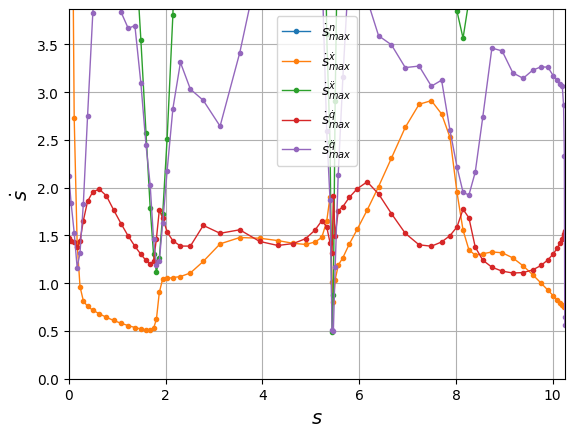

In [9]:
sd_bounds = plot_path_bounds(path_kin, path_con)


### Generate time-optimal trajectory

The next step is to solve the time-parameterization problem. The optimizer minimizes execution time subject to the path-dependent bounds derived from the active constraints.


RobotBlockSet provides the `timeopttraj` function for computing the time-optimal path parameterization.

| Argument | Description |
| --- | --- |
| `path_kin` | `path_kinematics` object describing the path geometry and derivatives used during optimization. |
| `path_con` | `path_constraints` object containing the velocity and acceleration limits in Cartesian and/or joint space. |
| `s0` | Initial value of the path parameter `s`. Default: `0`. |
| `send` | Final value of the path parameter. If `None`, the last value in `path_kin.path_s` is used. |
| `sd0` | Initial path velocity $\dot{s}$. Default: `0`. |
| `sdend` | Final path velocity $\dot{s}$. Default: `0`. |
| `tsamp` | Sampling period used for integrating and returning the trajectory. Default: `0.01`. |
| `plot` | If `True`, plot the feasible $s$-$\dot{s}$ region and the forward/backward integration steps. Default: `False`. |
| `sd_bounds` | Optional precomputed path-velocity bounds for plotting. If omitted and `plot=True`, they are computed internally. |

The function returns time samples `T`, path position `sp`, path velocity `sv`, and path acceleration `sa`.


In [10]:
T, sp, sv, sa = timeopttraj(path_kin, path_con, tsamp=0.01)

### Prepare joint and/or Cartesian trajectories

After optimization, the path-space trajectory is mapped back to Cartesian space and/or joint space for visualization and execution.


In [11]:
if Cartesian:
    path_rx, path_rxd, path_rxdd = path_kin.s2x(sp, sv, sa)
    path_rq, path_rqd, path_rqdd = path_kin.s2q_x(sp, sv, sa)
else:
    path_rq, path_rqd, path_rqdd = path_kin.s2x(sp, sv, sa)
    n = path_rq.shape[0]
    path_rx = np.zeros((n, 7))
    for i in range(n):
        path_rx[i, :] = dkin(path_rq[i, :])[0]
    path_rx = uniqueCartesianPath(path_rx)
    path_rxd = gradientCartesianPath(path_rx, T)
    path_rxdd = gradientPath(path_rxd, T)

The path-space trajectory is plotted as:


Text(76.84722222222221, 0.5, '$\\ddot s$')

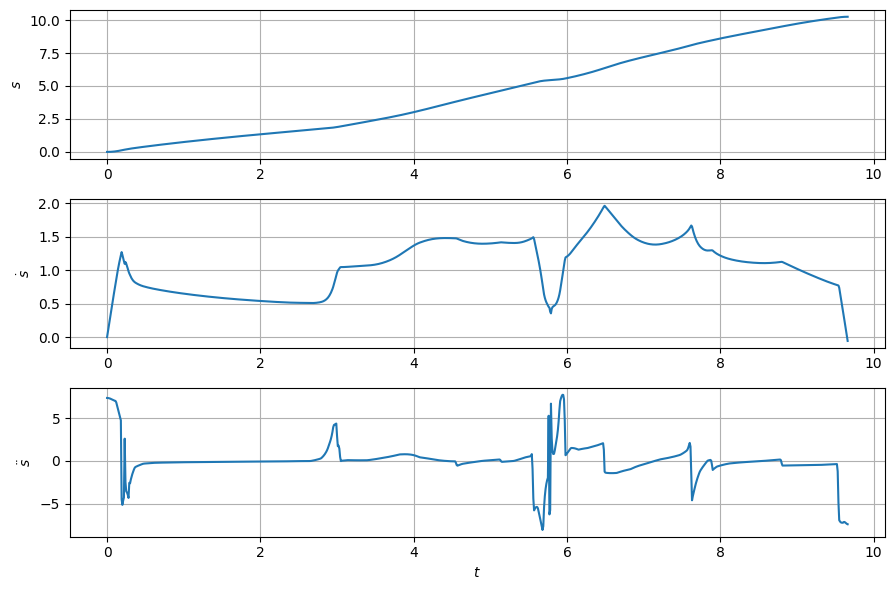

In [12]:
_, ax = plotjtraj(T, sp, sv, sa, fig_num="Time optimal path trajectory")
ax[0].set_ylabel("$s$")
ax[1].set_ylabel("$\dot s$")
ax[2].set_ylabel("$\ddot s$")

The task-space trajectory is plotted as:


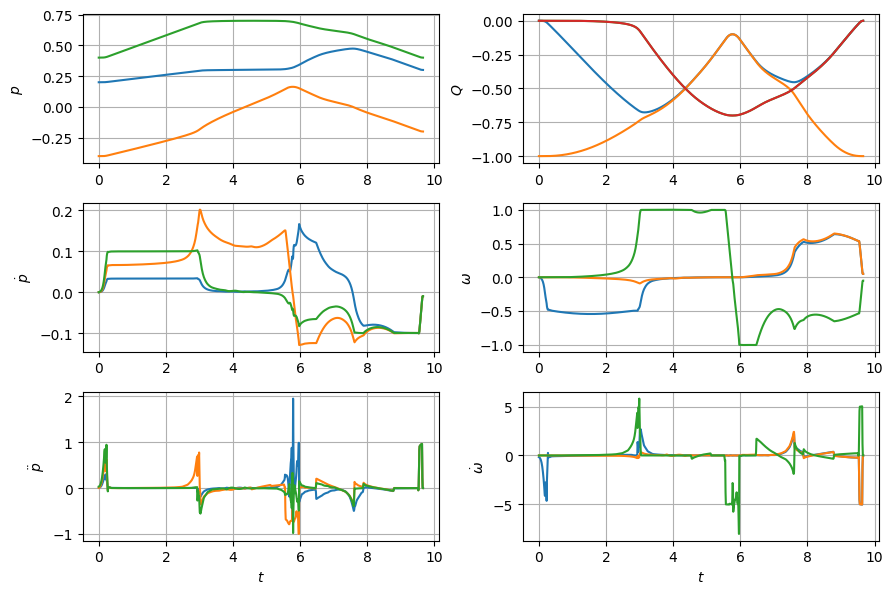

In [13]:
_ = plotctraj(T, path_rx, fig_num="Time optimal task trajectory")


The joint-space trajectory is plotted as:


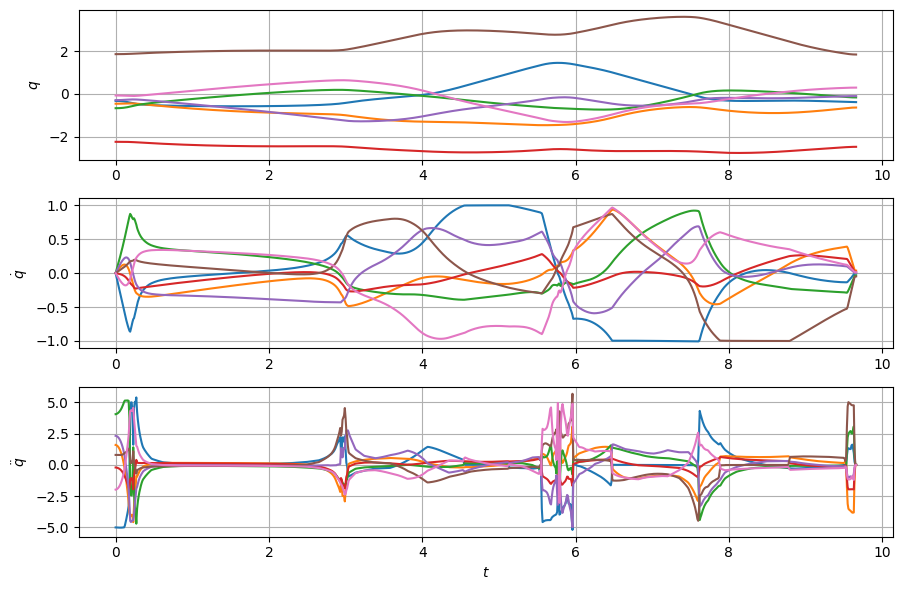

In [14]:
_ = plotjtraj(T, path_rq, fig_num="Time optimal joint trajectory")


## Direct joint-space formulation

For a path already represented in joint space, RobotBlockSet provides the higher-level helper `timeopt_joint_traj`. It returns time-optimal joint positions, velocities, and accelerations without requiring you to explicitly construct the intermediate path-space objects.

| Argument | Description |
| --- | --- |
| `path_q` | Array of joint-space waypoints with shape `(n, nj)` defining the path to parameterize. |
| `path_con` | `path_constraints` object containing the velocity and acceleration limits used by the optimizer. |
| `dkin` | Optional forward-kinematics callable used when Cartesian constraints need to be evaluated from the joint path. |
| `scale` | SE(3) norm scale factor or factors used inside the path kinematics model. Default: `(1.0, 1.0)`. |
| `s0` | Initial value of the path parameter `s`. Default: `0`. |
| `send` | Final value of the path parameter. If `None`, the last path sample is used. |
| `sd0` | Initial path velocity $\dot{s}$. Default: `0`. |
| `sdend` | Final path velocity $\dot{s}$. Default: `0`. |
| `tsamp` | Sampling period of the generated optimal trajectory. Default: `0.01`. |
| `plot` | If `True`, enable the same diagnostic plot as `timeopttraj`. Default: `False`. |
| `sd_bounds` | Optional precomputed path-velocity bounds passed through to `timeopttraj` when plotting. |


> **Note:** If no direct kinematics function is provided through `dkin`, task-space constraints are ignored.


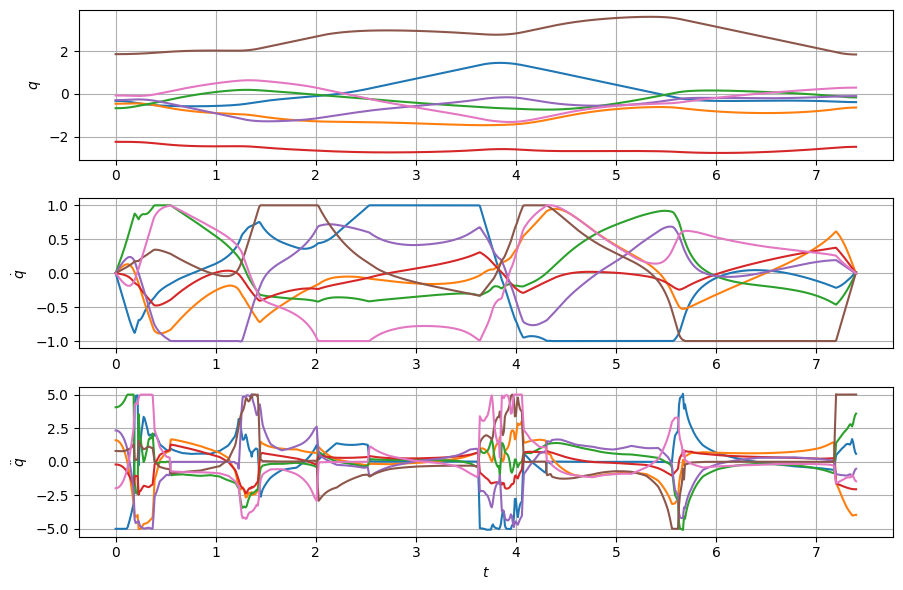

In [17]:
T, rqt, rqdt, rqddt = timeopt_joint_traj(qi, path_con)

_ = plotjtraj(T, rqt, rqdt, rqddt, fig_num="Time optimal joint trajectory 1", fig_size=(9, 6))


## Recommendations

Execute the generated trajectory with `JPath` or `CPath`, depending on whether the trajectory is defined in joint space or task space.

For redundant robots, prefer joint-space time-optimal trajectories when joint limits are important. If a Cartesian trajectory is optimized with joint constraints and then executed with `CPath`, the inverse-kinematics solution used during execution may differ from the joint states used during optimization. In that case, the original joint-limit guarantees may no longer hold.
